# Task 3 — Image Quality Metrics (Production QC)

This notebook implements **two complementary image-quality metrics** for the provided production dataset:

1. **SNR** (signal-to-noise ratio): detects low-signal / noisy acquisitions.
2. **Sharpness** via **variance of the 3D Laplacian**: detects blur/motion and loss of high-frequency content.

Together, these separate images into **good** and **bad** quality groups and provide **threshold guidance** for deployment.


## Dataset
- Input file: `Task3/Images/images.nii.gz` (provided here as `images.nii`)
- The loaded array has shape **(X, Y, Z, N)** where **N is the number of production images**.
- Indexing in outputs below is **0-based** (Python convention). If needed, convert to 1-based by adding 1.


In [1]:
import os, struct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Minimal NIfTI-1 .nii loader (no external deps) ----------
def load_nifti_nii(path):
    with open(path, "rb") as f:
        hdr = f.read(348)
    sizeof_hdr = struct.unpack("<i", hdr[0:4])[0]
    if sizeof_hdr != 348:
        sizeof_hdr = struct.unpack(">i", hdr[0:4])[0]
        endian = ">"
        if sizeof_hdr != 348:
            raise ValueError("Not a NIfTI-1 .nii file (unexpected header size).")
    else:
        endian = "<"

    dim = struct.unpack(endian + "8h", hdr[40:40+16])
    ndim = dim[0]
    shape = tuple(int(d) for d in dim[1:ndim+1])

    datatype = struct.unpack(endian + "h", hdr[70:72])[0]
    vox_offset = struct.unpack(endian + "f", hdr[108:112])[0]
    scl_slope = struct.unpack(endian + "f", hdr[112:116])[0]
    scl_inter = struct.unpack(endian + "f", hdr[116:120])[0]

    dt_map = {
        2: np.uint8, 4: np.int16, 8: np.int32, 16: np.float32, 64: np.float64,
        256: np.int8, 512: np.uint16, 768: np.uint32, 1024: np.int64, 1280: np.uint64,
    }
    if datatype not in dt_map:
        raise ValueError(f"Unsupported NIfTI datatype code: {datatype}")

    np_dtype = dt_map[datatype]
    mm = np.memmap(path, dtype=np_dtype, mode="r", offset=int(vox_offset))
    nvox = int(np.prod(shape))
    data = np.array(mm[:nvox]).reshape(shape, order="F").astype(np.float32)

    if scl_slope == 0.0:
        scl_slope = 1.0
    if scl_slope != 1.0 or scl_inter != 0.0:
        data = data * float(scl_slope) + float(scl_inter)

    return data, {"shape": shape, "datatype": datatype, "vox_offset": vox_offset,
                  "scl_slope": scl_slope, "scl_inter": scl_inter, "endian": endian}

# Path (edit if you move the file)
path = "images.nii"  # update if needed
data, meta = load_nifti_nii(path)
print("Meta:", meta)
print("Data shape:", data.shape, "dtype:", data.dtype, "min/max:", float(data.min()), float(data.max()))



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/u1982583/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/u1982583/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/u1982583/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/Us

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/u1982583/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/u1982583/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/u1982583/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/Us

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/u1982583/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/u1982583/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/u1982583/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/Us

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/u1982583/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/u1982583/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/u1982583/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/Us

AttributeError: _ARRAY_API not found

Meta: {'shape': (81, 81, 25, 80), 'datatype': 4, 'vox_offset': 352.0, 'scl_slope': 1.0, 'scl_inter': 0.0, 'endian': '<'}
Data shape: (81, 81, 25, 80) dtype: float32 min/max: 4.0 1000.0


In [2]:
def compute_metrics(vol):
    # Foreground mask via robust thresholding
    vol = np.asarray(vol, dtype=np.float32)
    flat = vol.reshape(-1)

    p98 = np.percentile(flat, 98)
    thr = 0.1 * p98
    fg = vol > thr
    if fg.sum() < 100:
        thr = np.percentile(flat, 85)
        fg = vol > thr

    bg = vol[~fg]
    if bg.size == 0:
        bg = flat

    # Noise from darkest 20% of background
    p20 = np.percentile(bg, 20)
    noise = bg[bg <= p20]
    if noise.size < 50:
        noise = bg

    sigma = float(np.std(noise) + 1e-6)
    mu = float(np.mean(vol[fg]) if fg.sum() else np.mean(vol))
    snr = mu / sigma

    # 3D 6-neighbour Laplacian
    I = vol
    lap = (-6.0 * I
           + np.roll(I, 1, axis=0) + np.roll(I, -1, axis=0)
           + np.roll(I, 1, axis=1) + np.roll(I, -1, axis=1)
           + np.roll(I, 1, axis=2) + np.roll(I, -1, axis=2))
    lap_fg = lap[fg] if fg.sum() else lap.reshape(-1)
    sharp = float(np.var(lap_fg))

    return snr, sharp

# Compute per-image metrics
n_imgs = data.shape[3] if data.ndim == 4 else 1
snrs, sharps = [], []
for i in range(n_imgs):
    vol = data[..., i] if data.ndim == 4 else data
    s, sh = compute_metrics(vol)
    snrs.append(s); sharps.append(sh)

df = pd.DataFrame({"index": np.arange(n_imgs), "snr": snrs, "sharpness_var_lap": sharps})
df.describe()


,index,snr,sharpness_var_lap
count,80.0000,80.000000,80.000000
mean,39.5000,63.369454,194548.812891
std,23.2379,25.895453,107299.786893
min,0.0000,30.952228,68266.484375
25%,19.7500,44.206137,124501.742188
50%,39.5000,52.101344,148660.820312
75%,59.2500,91.446445,209059.320312
max,79.0000,138.316009,476532.000000


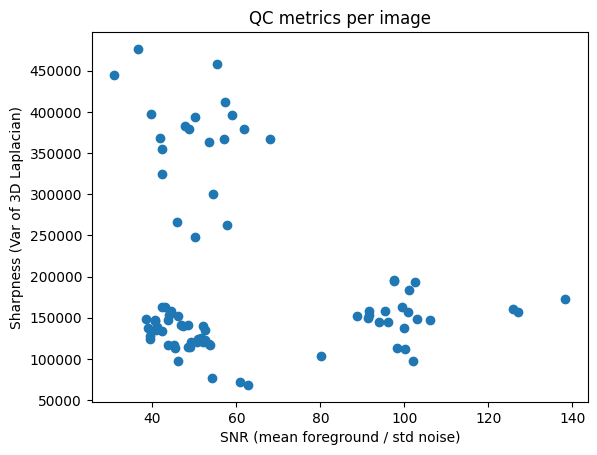

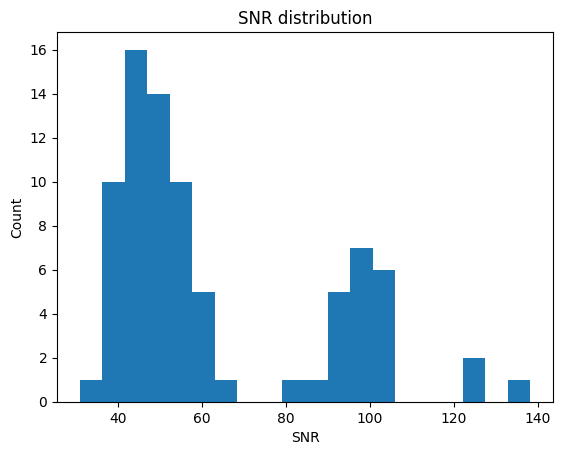

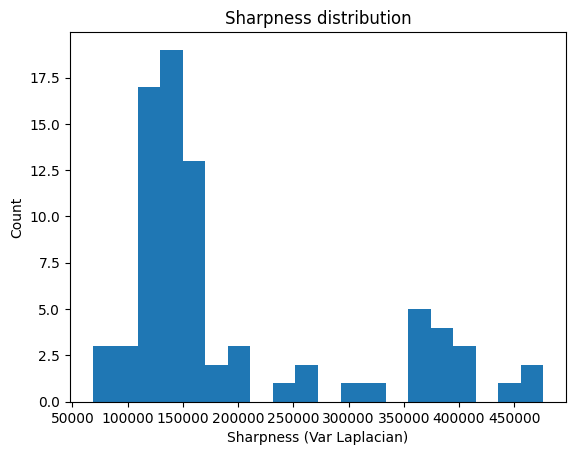

In [3]:
plt.figure()
plt.scatter(df["snr"], df["sharpness_var_lap"])
plt.xlabel("SNR (mean foreground / std noise)")
plt.ylabel("Sharpness (Var of 3D Laplacian)")
plt.title("QC metrics per image")
plt.show()

plt.figure()
plt.hist(df["snr"], bins=20)
plt.xlabel("SNR")
plt.ylabel("Count")
plt.title("SNR distribution")
plt.show()

plt.figure()
plt.hist(df["sharpness_var_lap"], bins=20)
plt.xlabel("Sharpness (Var Laplacian)")
plt.ylabel("Count")
plt.title("Sharpness distribution")
plt.show()


## Thresholding strategy (deployment guidance)

Production datasets often fail via two dominant modes:

- **Low SNR** (noisy / low-signal scans, gain issues, drift)
- **Low sharpness** (motion blur, conveyor synchronisation, gradient issues)

A robust and interpretable deployment rule is:

\[
\textbf{Good} \iff SNR \ge T_{SNR} \;\wedge\; Sharpness \ge T_{Sharp}
\]

Here we set thresholds using the **15th percentile** of the dataset as a conservative starting point.
In production, you can tune these using labeled QC outcomes or by targeting a chosen reject rate.


In [4]:
snr_thr = float(np.percentile(df["snr"], 15))
sharp_thr = float(np.percentile(df["sharpness_var_lap"], 15))

df["is_good"] = (df["snr"] >= snr_thr) & (df["sharpness_var_lap"] >= sharp_thr)

good_idx = df[df["is_good"]]["index"].tolist()
bad_idx = df[~df["is_good"]]["index"].tolist()

print("Thresholds:")
print("  T_SNR   =", snr_thr)
print("  T_Sharp =", sharp_thr)
print()
print(f"Good images: {len(good_idx)} / {len(df)}")
print(f"Bad images : {len(bad_idx)} / {len(df)}")


Thresholds:
  T_SNR   = 42.190447543611725
  T_Sharp = 116381.92109375

Good images: 56 / 80
Bad images : 24 / 80


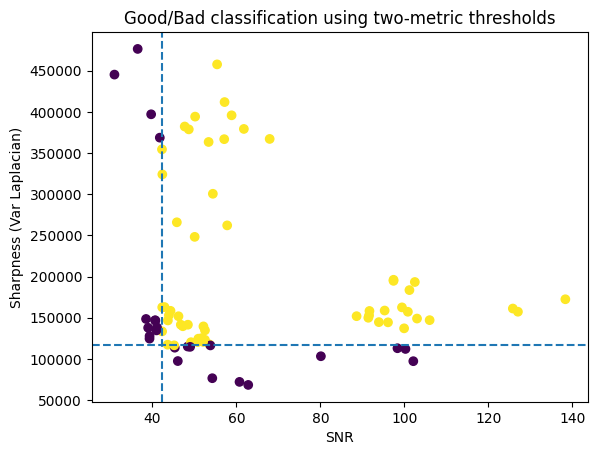

In [5]:
plt.figure()
plt.scatter(df["snr"], df["sharpness_var_lap"], c=df["is_good"].astype(int))
plt.axvline(snr_thr, linestyle="--")
plt.axhline(sharp_thr, linestyle="--")
plt.xlabel("SNR")
plt.ylabel("Sharpness (Var Laplacian)")
plt.title("Good/Bad classification using two-metric thresholds")
plt.show()


## Required outputs

- Indexes of good-quality images
- Indexes of bad-quality images

(0-based indexing)


In [6]:
print("GOOD indexes (0-based):")
print(good_idx)
print()
print("BAD indexes (0-based):")
print(bad_idx)

df.to_csv("task3_qc_metrics_with_labels.csv", index=False)
print("\nSaved: task3_qc_metrics_with_labels.csv")


GOOD indexes (0-based):
[0, 1, 2, 3, 4, 6, 8, 9, 10, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 28, 29, 30, 31, 32, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 48, 49, 50, 51, 52, 54, 56, 57, 59, 62, 64, 66, 70, 71, 73, 74, 75, 77, 79]

BAD indexes (0-based):
[5, 7, 11, 12, 14, 26, 27, 34, 37, 44, 46, 53, 55, 58, 60, 61, 63, 65, 67, 68, 69, 72, 76, 78]

Saved: task3_qc_metrics_with_labels.csv
